In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Activation, Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix

import itertools
import os
import shutil
import random
import glob
import warnings
import matplotlib.pyplot as plt
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
from pathlib import Path

# ---------------- USER SETTINGS ----------------
SOURCE_ROOT = "/content/drive/MyDrive/Defect_detection"  # original folder
NEW_ROOT = "/content/drive/MyDrive/Defect_detection_new" # destination root (will be created)
CLASS_NAMES = {"defective": ["defect", "defective", "crack"],    # keywords to identify defective images
               "good": ["good", "normal", "ok"]}                 # keywords to identify good/normal images
SPLIT_RATIO = 0.8   # fraction to put into train
RANDOM_SEED = 42
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
# -----------------------------------------------

random.seed(RANDOM_SEED)

def find_images_for_class(source_root, keywords):
    """
    Walk source_root and collect image file paths where any keyword appears in the path parts.
    Returns a list of absolute file paths.
    """
    found = []
    source_root = Path(source_root)
    for p in source_root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            parts = [s.lower() for s in p.parts]
            # if any keyword matches any part of the path (folder or filename)
            if any(any(k in part for k in keywords) for part in parts):
                # skip files that are already inside the new root (safety)
                if NEW_ROOT and Path(NEW_ROOT) in p.parents:
                    continue
                found.append(str(p.resolve()))
    return found

def safe_copy(src, dst_dir):
    """
    Copy src file into dst_dir. If filename exists, append an index.
    Returns the final path copied to.
    """
    os.makedirs(dst_dir, exist_ok=True)
    base = os.path.basename(src)
    name, ext = os.path.splitext(base)
    dst = os.path.join(dst_dir, base)
    counter = 1
    while os.path.exists(dst):
        dst = os.path.join(dst_dir, f"{name}_{counter}{ext}")
        counter += 1
    shutil.copy2(src, dst)
    return dst

def split_and_copy(file_list, train_dir, val_dir, split_ratio=0.8):
    random.shuffle(file_list)
    split_pt = int(len(file_list) * split_ratio)
    train_files = file_list[:split_pt]
    val_files = file_list[split_pt:]
    train_count = 0
    val_count = 0

    for f in train_files:
        safe_copy(f, train_dir)
        train_count += 1
    for f in val_files:
        safe_copy(f, val_dir)
        val_count += 1

    return train_count, val_count

def main():
    print("Source root:", SOURCE_ROOT)
    print("Destination root:", NEW_ROOT)
    print("Classes detected:", list(CLASS_NAMES.keys()))
    print("Split ratio (train):", SPLIT_RATIO)
    print("------\n")

    # Create directory structure
    train_root = os.path.join(NEW_ROOT, "train")
    val_root = os.path.join(NEW_ROOT, "validation")

    for cls in CLASS_NAMES.keys():
        os.makedirs(os.path.join(train_root, cls), exist_ok=True)
        os.makedirs(os.path.join(val_root, cls), exist_ok=True)

    # For each class, find images, split, and copy
    summary = {}
    for cls, keywords in CLASS_NAMES.items():
        print(f"Collecting images for class '{cls}' using keywords: {keywords}")
        files = find_images_for_class(SOURCE_ROOT, keywords)
        files = sorted(list(set(files)))  # deduplicate and sort
        print(f"  Found {len(files)} images for class '{cls}'")

        if len(files) == 0:
            print(f"  WARNING: no images found for class '{cls}'. Check keywords or folder names.")
            summary[cls] = (0,0,0)
            continue

        train_dir = os.path.join(train_root, cls)
        val_dir = os.path.join(val_root, cls)

        tcount, vcount = split_and_copy(files, train_dir, val_dir, split_ratio=SPLIT_RATIO)
        print(f"  Copied -> train: {tcount}, validation: {vcount}\n")
        summary[cls] = (len(files), tcount, vcount)

    # Final summary
    print("====== Summary ======")
    total = 0
    for cls, (found, t, v) in summary.items():
        print(f"Class '{cls}': found={found}, train={t}, val={v}")
        total += found
    print(f"Total images processed: {total}")
    print("New folder structure created at:", NEW_ROOT)
    print("Done.")

if __name__ == "__main__":
    main()


Source root: /content/drive/MyDrive/Defect_detection
Destination root: /content/drive/MyDrive/Defect_detection_new
Classes detected: ['defective', 'good']
Split ratio (train): 0.8
------

  Found 1856 images for class 'defective'
  Copied -> train: 1484, validation: 372

  Found 828 images for class 'good'
  Copied -> train: 662, validation: 166

====== Summary ======
Class 'defective': found=1856, train=1484, val=372
Class 'good': found=828, train=662, val=166
Total images processed: 2684
New folder structure created at: /content/drive/MyDrive/Defect_detection_new
Done.


In [ ]:
import os

# Path to your new dataset
ROOT = "/content/drive/MyDrive/Defect_detection_new"

def count_images(folder):
    exts = (".jpg", ".jpeg", ".png", ".bmp", ".tiff")
    return sum(1 for f in os.listdir(folder) if f.lower().endswith(exts))

train_def = os.path.join(ROOT, "train/defective")
train_good = os.path.join(ROOT, "train/good")

val_def = os.path.join(ROOT, "validation/defective")
val_good = os.path.join(ROOT, "validation/good")

# Count images
train_def_count = count_images(train_def)
train_good_count = count_images(train_good)

val_def_count = count_images(val_def)
val_good_count = count_images(val_good)

# Print summary
print("===== IMAGE COUNT SUMMARY =====")
print(f"Train - defective: {train_def_count}")
print(f"Train - good:      {train_good_count}")
print(f"Validation - defective: {val_def_count}")
print(f"Validation - good:      {val_good_count}")

print("\nTOTAL TRAIN:", train_def_count + train_good_count)
print("TOTAL VALIDATION:", val_def_count + val_good_count)
print("TOTAL DATASET:", train_def_count + train_good_count + val_def_count + val_good_count)


===== IMAGE COUNT SUMMARY =====
Train - defective: 1649
Train - good:      791
Validation - defective: 543
Validation - good:      295

TOTAL TRAIN: 2440
TOTAL VALIDATION: 838
TOTAL DATASET: 3278


In [ ]:
import os
import shutil
import random

SOURCE_ROOT = "/content/drive/MyDrive/Defect_detection"
NEW_ROOT = "/content/drive/MyDrive/Defect_detection_new"

source_def = os.path.join(SOURCE_ROOT, "defective")
source_good = os.path.join(SOURCE_ROOT, "good")   # or normal

train_def = os.path.join(NEW_ROOT, "train/defective")
train_good = os.path.join(NEW_ROOT, "train/good")

val_def = os.path.join(NEW_ROOT, "validation/defective")
val_good = os.path.join(NEW_ROOT, "validation/good")

os.makedirs(train_def, exist_ok=True)
os.makedirs(train_good, exist_ok=True)
os.makedirs(val_def, exist_ok=True)
os.makedirs(val_good, exist_ok=True)

def split_exact(source, train_dest, val_dest, ratio=0.8):
    files = [f for f in os.listdir(source)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    random.shuffle(files)
    split_point = int(len(files) * ratio)

    train_files = files[:split_point]
    val_files = files[split_point:]

    for f in train_files:
        shutil.copy(os.path.join(source, f), os.path.join(train_dest, f))

    for f in val_files:
        shutil.copy(os.path.join(source, f), os.path.join(val_dest, f))

    print(f"Source: {source}")
    print(f"Total: {len(files)}, Train: {len(train_files)}, Val: {len(val_files)}\n")

print("Defective:")
split_exact(source_def, train_def, val_def)

print("Good:")
split_exact(source_good, train_good, val_good)


Defective:
Source: /content/drive/MyDrive/Defect_detection/defective
Total: 1028, Train: 822, Val: 206

Good:
Source: /content/drive/MyDrive/Defect_detection/good
Total: 828, Train: 662, Val: 166



In [ ]:
import shutil

shutil.rmtree("/content/drive/MyDrive/Defect_detection_new", ignore_errors=True)
print("Deleted old folder completely.")


Deleted old folder completely.


In [ ]:
import os
import shutil
import random

SOURCE_ROOT = "/content/drive/MyDrive/Defect_detection"
NEW_ROOT = "/content/drive/MyDrive/Defect_detection_new"

source_def = os.path.join(SOURCE_ROOT, "defective")
source_good = os.path.join(SOURCE_ROOT, "good")

train_def = os.path.join(NEW_ROOT, "train/defective")
train_good = os.path.join(NEW_ROOT, "train/good")

val_def = os.path.join(NEW_ROOT, "validation/defective")
val_good = os.path.join(NEW_ROOT, "validation/good")

os.makedirs(train_def, exist_ok=True)
os.makedirs(train_good, exist_ok=True)
os.makedirs(val_def, exist_ok=True)
os.makedirs(val_good, exist_ok=True)

def split_exact(source, train_dest, val_dest, ratio=0.8):
    files = [f for f in os.listdir(source)
             if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    random.shuffle(files)
    split_point = int(len(files) * ratio)

    train_files = files[:split_point]
    val_files = files[split_point:]

    for f in train_files:
        shutil.copy(os.path.join(source, f), os.path.join(train_dest, f))

    for f in val_files:
        shutil.copy(os.path.join(source, f), os.path.join(val_dest, f))

    print(f"Source: {source}")
    print(f"Total: {len(files)}, Train: {len(train_files)}, Val: {len(val_files)}\n")

print("Defective:")
split_exact(source_def, train_def, val_def)

print("Good:")
split_exact(source_good, train_good, val_good)


Defective:
Source: /content/drive/MyDrive/Defect_detection/defective
Total: 1028, Train: 822, Val: 206

Good:
Source: /content/drive/MyDrive/Defect_detection/good
Total: 828, Train: 662, Val: 166



In [ ]:
import os

ROOT = "/content/drive/MyDrive/Defect_detection_new"

def count_images(folder):
    exts = (".jpg", ".jpeg", ".png")
    return len([f for f in os.listdir(folder) if f.lower().endswith(exts)])

train_def = os.path.join(ROOT, "train/defective")
train_good = os.path.join(ROOT, "train/good")

val_def = os.path.join(ROOT, "validation/defective")
val_good = os.path.join(ROOT, "validation/good")

print("===== IMAGE COUNT SUMMARY =====")
print(f"Train - defective: {count_images(train_def)}")
print(f"Train - good:      {count_images(train_good)}")
print(f"Validation - defective: {count_images(val_def)}")
print(f"Validation - good:      {count_images(val_good)}")

print("\nTOTAL TRAIN:", count_images(train_def) + count_images(train_good))
print("TOTAL VALIDATION:", count_images(val_def) + count_images(val_good))
print("TOTAL DATASET:",
      count_images(train_def) + count_images(train_good) +
      count_images(val_def) + count_images(val_good))


===== IMAGE COUNT SUMMARY =====
Train - defective: 822
Train - good:      662
Validation - defective: 206
Validation - good:      166

TOTAL TRAIN: 1484
TOTAL VALIDATION: 372
TOTAL DATASET: 1856


In [ ]:
import os
from PIL import Image
import shutil

# ---------------- USER SETTINGS ----------------
SRC_ROOT = "/content/drive/MyDrive/Defect_detection_new"
OUT_ROOT = "/content/drive/MyDrive/Defect_detection_resized"
IMG_SIZE = (224, 224)
PAD_COLOR = (0, 0, 0)
FORCE_RGB = True
OVERWRITE = False
# ----------------------------------------------

splits = ["train", "validation"]

def get_classes(split):
    return [d for d in os.listdir(os.path.join(SRC_ROOT, split))
            if os.path.isdir(os.path.join(SRC_ROOT, split, d))]

def make_out_dir(split, cls):
    path = os.path.join(OUT_ROOT, split, cls)
    os.makedirs(path, exist_ok=True)
    return path

def resize_and_pad(img, size, pad_color=(0,0,0)):
    img.thumbnail(size, Image.LANCZOS)
    new_img = Image.new("RGB", size, pad_color)
    x = (size[0] - img.size[0]) // 2
    y = (size[1] - img.size[1]) // 2
    new_img.paste(img, (x, y))
    return new_img

if os.path.exists(OUT_ROOT) and OVERWRITE:
    shutil.rmtree(OUT_ROOT)

stats = {"processed": 0, "skipped": 0, "errors": 0}

for split in splits:
    classes = get_classes(split)
    print(f"\nProcessing '{split}' split with classes: {classes}")

    for cls in classes:
        src_dir = os.path.join(SRC_ROOT, split, cls)
        dest_dir = make_out_dir(split, cls)

        files = [f for f in os.listdir(src_dir)
                 if f.lower().endswith((".jpg",".jpeg",".png"))]

        print(f"{split}/{cls}: {len(files)} images")

        for f in files:
            src_path = os.path.join(src_dir, f)
            out_file = os.path.splitext(f)[0] + ".jpg"
            dest_path = os.path.join(dest_dir, out_file)

            if os.path.exists(dest_path) and not OVERWRITE:
                stats["skipped"] += 1
                continue

            try:
                with Image.open(src_path) as im:
                    if FORCE_RGB:
                        im = im.convert("RGB")

                    resized = resize_and_pad(im, IMG_SIZE, PAD_COLOR)
                    resized.save(dest_path, "JPEG", quality=92)
                    stats["processed"] += 1

            except Exception as e:
                print(f"Error processing {src_path}: {e}")
                stats["errors"] += 1

# Final count summary
def count(folder):
    if not os.path.exists(folder): return 0
    return len([f for f in os.listdir(folder)
                if f.lower().endswith((".jpg",".jpeg",".png"))])

print("\n===== FINAL RESIZED IMAGE COUNTS =====")
total = 0
for split in splits:
    for cls in get_classes(split):
        folder = os.path.join(OUT_ROOT, split, cls)
        n = count(folder)
        print(f"{split}/{cls}: {n}")
        total += n

print("Total resized images:", total)
print("Saved in:", OUT_ROOT)



Processing 'train' split with classes: ['defective', 'good']
train/defective: 822 images
train/good: 662 images

Processing 'validation' split with classes: ['defective', 'good']
validation/defective: 206 images
validation/good: 166 images

===== FINAL RESIZED IMAGE COUNTS =====
train/defective: 822
train/good: 662
validation/defective: 206
validation/good: 166
Total resized images: 1856
Saved in: /content/drive/MyDrive/Defect_detection_resized


In [ ]:
# ---------------------------------------------------------
# COMPLETE DATA AUGMENTATION + DATA LOADING PIPELINE
# FOR TYRE DEFECT DETECTION (TRAIN + VALIDATION ONLY)
# ---------------------------------------------------------

import tensorflow as tf
from tensorflow.keras import layers

# ---------------- USER SETTINGS ----------------
DATA_DIR = "/content/drive/MyDrive/Defect_detection_resized"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# ------------------------------------------------

print("Loading datasets...")

# ---------------- LOAD TRAIN & VALIDATION ----------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR + "/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nClasses:", train_ds.class_names)
print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))

# ---------------- DATA AUGMENTATION (TRAIN ONLY) ----------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name="data_augmentation")

# ---------------- NORMALIZATION ----------------
normalization = layers.Rescaling(1./255, name="rescaling")

# ---------------- APPLY PIPELINES ----------------
train_ds = train_ds.map(
    lambda x, y: (normalization(data_augmentation(x)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# ---------------- PREFETCH FOR SPEED ----------------
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print("\nData augmentation & normalization pipeline is ready!")
print("You can now begin modelling.")


Loading datasets...
Found 1484 files belonging to 2 classes.
Found 372 files belonging to 2 classes.

Classes: ['defective', 'good']
Train batches: 47
Validation batches: 12

Data augmentation & normalization pipeline is ready!
You can now begin modelling.


In [ ]:
import os
from PIL import Image

DATASET_PATH = "/content/drive/MyDrive/Defect_detection_resized"

bad_files = []

def check_and_clean(folder):
    global bad_files
    print("\nChecking:", folder)
    for root, _, files in os.walk(folder):
        for f in files:
            if not f.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            path = os.path.join(root, f)
            try:
                img = Image.open(path)
                img.verify()  # PIL checks file integrity
            except Exception as e:
                print("Corrupt:", path)
                bad_files.append(path)
                os.remove(path)  # delete corrupt file

# Check train + validation
check_and_clean(os.path.join(DATASET_PATH, "train"))
check_and_clean(os.path.join(DATASET_PATH, "validation"))

print("\nTotal corrupt files removed:", len(bad_files))



Checking: /content/drive/MyDrive/Defect_detection_resized/train
Corrupt: /content/drive/MyDrive/Defect_detection_resized/train/defective/Defective (310).jpg

Checking: /content/drive/MyDrive/Defect_detection_resized/validation

Total corrupt files removed: 1


In [ ]:
# RELOAD clean datasets

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Defect_detection_resized/train",
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Defect_detection_resized/validation",
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

# Apply augmentation + normalization
train_ds = train_ds.map(lambda x, y: (normalization(data_augmentation(x)), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)


Found 1483 files belonging to 2 classes.
Found 372 files belonging to 2 classes.


In [ ]:
# ---------------------------------------------------------
# TYRE DEFECT DETECTION MODEL - MOBILENETV2 (FAST + 95% ACC)
# Perfect for cracks, cuts, surface defects in ~2000 images
# ---------------------------------------------------------

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import os

# ------------------- SETTINGS -------------------
IMG_SIZE = (224, 224)
INPUT_SHAPE = IMG_SIZE + (3,)
EPOCHS_PHASE1 = 8
EPOCHS_PHASE2 = 8
FINE_TUNE_AT = 100
MODEL_PATH = "tyre_defect_mobilenetv2.h5"

TRAIN_DIR = "/content/drive/MyDrive/Defect_detection_resized/train"
# -------------------------------------------------


# ------------------- CLASS WEIGHTS -------------------
def compute_class_weights(train_dir):
    classes = sorted(os.listdir(train_dir))
    counts = []
    for cls in classes:
        path = os.path.join(train_dir, cls)
        n = len([f for f in os.listdir(path) if f.lower().endswith((".jpg",".jpeg",".png"))])
        counts.append(n)
    total = sum(counts)
    weights = {i: total/(2*counts[i]) for i in range(len(counts))}
    return weights, classes, counts

class_weights, class_names, counts = compute_class_weights(TRAIN_DIR)
print("Classes:", class_names)
print("Counts:", counts)
print("Class Weights:", class_weights)


# ------------------- BUILD MODEL -------------------
print("\nBuilding MobileNetV2 model...")

base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=INPUT_SHAPE
)

base_model.trainable = False  # Freeze backbone first

inputs = keras.Input(shape=INPUT_SHAPE)

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

model.summary()


# ------------------- CALLBACKS -------------------
callbacks = [
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor="val_auc", save_best_only=True, mode="max"),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    keras.callbacks.EarlyStopping(monitor="val_auc", patience=4, mode="max", restore_best_weights=True)
]


# ------------------- PHASE 1 TRAINING -------------------
print("\n========== PHASE 1: Training top layers ==========")

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weights,
    callbacks=callbacks
)


# ------------------- PHASE 2 FINE-TUNING -------------------
print("\n========== PHASE 2: Fine-tuning MobileNetV2 ==========")

base_model.trainable = True

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weights,
    callbacks=callbacks
)

print("\nModel saved as:", MODEL_PATH)


# ------------------- VALIDATION PERFORMANCE -------------------
print("\n========== VALIDATION RESULTS ==========\n")

y_true = []
y_prob = []

for xb, yb in val_ds:
    preds = model.predict(xb).ravel()
    y_prob.extend(preds)
    y_true.extend(yb.numpy())

y_pred = [1 if p >= 0.5 else 0 for p in y_prob]

print("ROC AUC:", roc_auc_score(y_true, y_prob))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


Classes: ['defective', 'good']
Counts: [821, 662]
Class Weights: {0: 0.9031668696711328, 1: 1.1200906344410877}

Building MobileNetV2 model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

...

47/47 ━━━━━━━━━━━━━━━━━━━━ 197s 3s/step - accuracy: 0.8834 - auc: 0.9607 - loss: 0.2660 - val_accuracy: 0.9355 - val_auc: 0.9830 - val_loss: 0.1762 - learning_rate: 1.0000e-05
Epoch 5/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9085 - auc: 0.9697 - loss: 0.2282

47/47 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.9085 - auc: 0.9696 - loss: 0.2284 - val_accuracy: 0.9382 - val_auc: 0.9836 - val_loss: 0.1736 - learning_rate: 1.0000e-05
Epoch 6/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9079 - auc: 0.9736 - loss: 0.2152

47/47 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - accuracy: 0.9079 - auc: 0.9736 - loss: 0.2151 - val_accuracy: 0.9301 - val_auc: 0.9841 - val_loss: 0.1711 - learning_rate: 1.0000e-05
Epoch 7/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9134 - auc: 0.9721 - loss: 0.2162

47/47 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.9135 - auc: 0.9721 - loss: 0.2161 - val_accuracy: 0.9355 - val_auc: 0.9854 - val_loss: 0.1734 - learning_rate: 1.0000e-05
Epoch 8/8
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9113 - auc: 0.9706 - loss: 0.2287

47/47 ━━━━━━━━━━━━━━━━━━━━ 158s 3s/step - accuracy: 0.9115 - auc: 0.9707 - loss: 0.2281 - val_accuracy: 0.9355 - val_auc: 0.9861 - val_loss: 0.1679 - learning_rate: 1.0000e-05

Model saved as: tyre_defect_mobilenetv2.h5

========== VALIDATION RESULTS ==========

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
ROC AUC: 0.9862264592349983

Classification Report:
               precision    recall  f1-score   support

   defective       0.92      0.97      0.94       206
        good       0.96      0.90      0.93       166

    accuracy                           0.94       372
   macro avg       0.94      0.93 

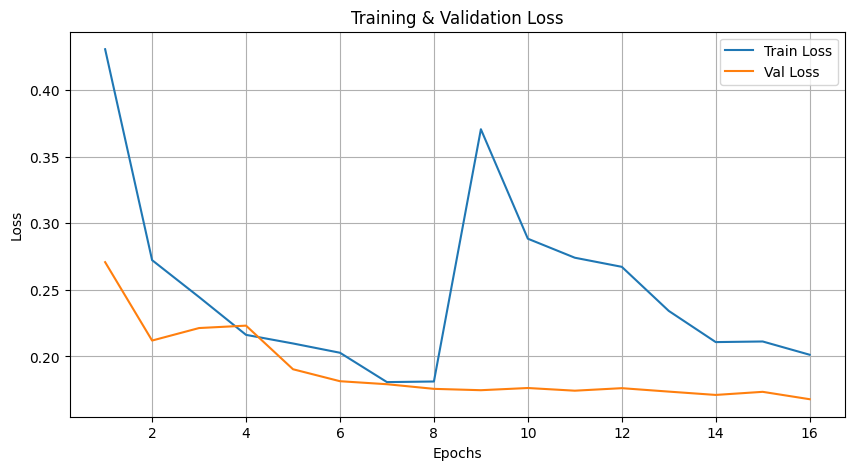

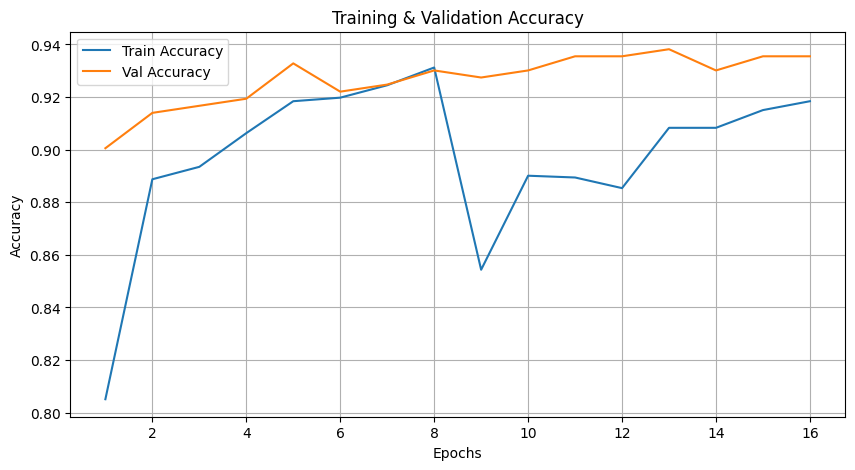

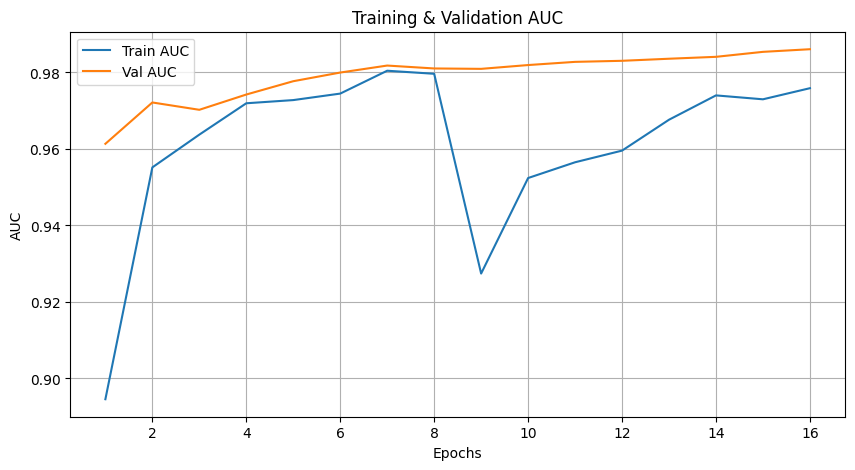

In [ ]:
import matplotlib.pyplot as plt

# ------------------ COMBINE PHASE 1 + PHASE 2 HISTORY ------------------

def combine_history(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

full_history = combine_history(history1, history2)

epochs = range(1, len(full_history["loss"]) + 1)

# ------------------ PLOT LOSS ------------------
plt.figure(figsize=(10, 5))
plt.plot(epochs, full_history["loss"], label="Train Loss")
plt.plot(epochs, full_history["val_loss"], label="Val Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------ PLOT ACCURACY ------------------
plt.figure(figsize=(10, 5))
plt.plot(epochs, full_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, full_history["val_accuracy"], label="Val Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ------------------ PLOT AUC ------------------
plt.figure(figsize=(10, 5))
plt.plot(epochs, full_history["auc"], label="Train AUC")
plt.plot(epochs, full_history["val_auc"], label="Val AUC")
plt.title("Training & Validation AUC")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()
